In [3]:
from time import perf_counter
import random
import string
import matplotlib.pyplot as plt
import sys
import os

In [4]:
sys.path.insert(0, os.path.abspath('..'))
from src.naive import edit_distance_naive
from src.memoized import edit_distance_memoized
from src.tabulation import edit_distance_tabulation, edit_distance_optimized

In [5]:
def generate_string_pair(length, num_edits=3):
    """Generate a random string and a mutated version with num_edits random edits."""
    base = ''.join(random.choices(string.ascii_lowercase, k=length))
    mutated = list(base)
    
    for _ in range(num_edits):
        op = random.choice(['insert', 'delete', 'replace'])
        if not mutated:
            op = 'insert'
        pos = random.randint(0, max(len(mutated) - 1, 0))
        
        if op == 'insert':
            mutated.insert(pos, random.choice(string.ascii_lowercase))
        elif op == 'delete':
            mutated.pop(pos)
        else:
            mutated[pos] = random.choice(string.ascii_lowercase)
    
    return base, ''.join(mutated)

In [6]:
generate_string_pair(10)

('nsalplcfma', 'nsoaplcfma')

In [7]:
def benchmark(func, s1, s2, runs=5):
    """Time a function over multiple runs and return the average time in seconds."""
    times = []
    for _ in range(runs):
        start = perf_counter()
        func(s1, s2)
        end = perf_counter()
        times.append(end - start)
    return sum(times) / len(times)

In [10]:
random.seed(42)

small_lengths = [5, 8, 10, 12, 15, 18, 20]
small_results = {'naive': [], 'memoized': [], 'tabulation': [], 'optimized': []}

for length in small_lengths:
    s1, s2 = generate_string_pair(length)
    print(f"Length {length}: '{s1[:20]}' vs '{s2[:20]}'")
    
    if length <= 12:
        t = benchmark(edit_distance_naive, s1, s2, runs=3)
        small_results['naive'].append(t)
        print(f"  Naive:       {t:.6f}s")
    else:
        small_results['naive'].append(None)
        print(f"  Naive:       SKIPPED (too slow)")
    
    t = benchmark(edit_distance_memoized, s1, s2, runs=3)
    small_results['memoized'].append(t)
    print(f"  Memoized:    {t:.6f}s")
    
    t = benchmark(edit_distance_tabulation, s1, s2, runs=3)
    small_results['tabulation'].append(t)
    print(f"  Tabulation:  {t:.6f}s")
    
    t = benchmark(edit_distance_optimized, s1, s2, runs=3)
    small_results['optimized'].append(t)
    print(f"  Optimized:   {t:.6f}s")
    
    print()

Length 5: 'qahft' vs 'gqahbc'
  Naive:       0.000161s
  Memoized:    0.000015s
  Tabulation:  0.000013s
  Optimized:   0.000003s

Length 8: 'gpossklh' vs 'gposklh'
  Naive:       0.000011s
  Memoized:    0.000010s
  Tabulation:  0.000013s
  Optimized:   0.000008s

Length 10: 'ftcjjigbld' vs 'fcjjusbld'
  Naive:       0.000618s
  Memoized:    0.000019s
  Tabulation:  0.000013s
  Optimized:   0.000009s

Length 12: 'ebruzwwjlvej' vs 'ebruwwwjlvfj'
  Naive:       0.288630s
  Memoized:    0.000049s
  Tabulation:  0.000018s
  Optimized:   0.000012s

Length 15: 'ngmhyrfitbvukbx' vs 'ngmyrfimbvukbw'
  Naive:       SKIPPED (too slow)
  Memoized:    0.000187s
  Tabulation:  0.000024s
  Optimized:   0.000017s

Length 18: 'xqddtotlpjzdmtwder' vs 'xqmdtotlrjzdmtder'
  Naive:       SKIPPED (too slow)
  Memoized:    0.000057s
  Tabulation:  0.000034s
  Optimized:   0.000023s

Length 20: 'wasrngqcllywgnexwhqp' vs 'tasrngqcllyywgnexywh'
  Naive:       SKIPPED (too slow)
  Memoized:    0.000053s
  Tabu

In [11]:
wide_lengths = [10, 25, 50, 100, 200, 500, 1000]
wide_results = {'memoized': [], 'tabulation': [], 'optimized': []}

for length in wide_lengths:
    s1, s2 = generate_string_pair(length)
    print(f"Length {length}:")
    
    t = benchmark(edit_distance_memoized, s1, s2, runs=3)
    wide_results['memoized'].append(t)
    print(f"  Memoized:    {t:.6f}s")
    
    t = benchmark(edit_distance_tabulation, s1, s2, runs=3)
    wide_results['tabulation'].append(t)
    print(f"  Tabulation:  {t:.6f}s")
    
    t = benchmark(edit_distance_optimized, s1, s2, runs=3)
    wide_results['optimized'].append(t)
    print(f"  Optimized:   {t:.6f}s")
    
    print()

Length 10:
  Memoized:    0.000026s
  Tabulation:  0.000011s
  Optimized:   0.000008s

Length 25:
  Memoized:    0.000078s
  Tabulation:  0.000057s
  Optimized:   0.000040s

Length 50:
  Memoized:    0.000440s
  Tabulation:  0.000224s
  Optimized:   0.000190s

Length 100:
  Memoized:    0.004097s
  Tabulation:  0.000939s
  Optimized:   0.000603s

Length 200:
  Memoized:    0.015601s
  Tabulation:  0.002990s
  Optimized:   0.002158s

Length 500:
  Memoized:    0.022329s
  Tabulation:  0.022629s
  Optimized:   0.016394s

Length 1000:
  Memoized:    0.397506s
  Tabulation:  0.101660s
  Optimized:   0.080865s



In [14]:
os.makedirs('../benchmarks', exist_ok=True)

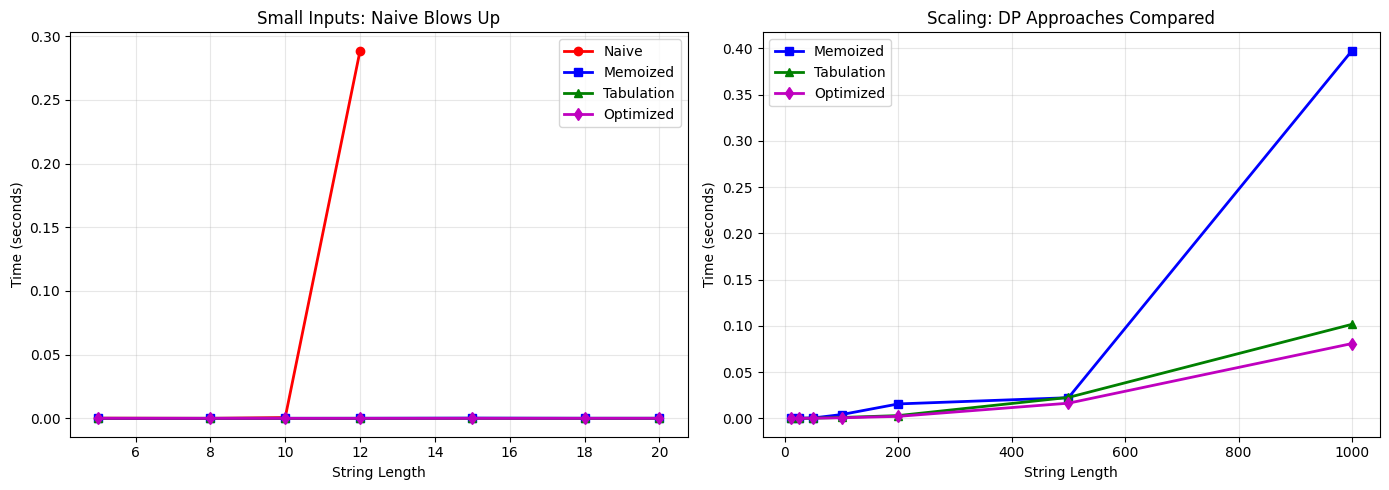

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Small range (all four)
naive_lengths = [l for l, t in zip(small_lengths, small_results['naive']) if t is not None]
naive_times = [t for t in small_results['naive'] if t is not None]

ax1.plot(naive_lengths, naive_times, 'ro-', label='Naive', linewidth=2)
ax1.plot(small_lengths, small_results['memoized'], 'bs-', label='Memoized', linewidth=2)
ax1.plot(small_lengths, small_results['tabulation'], 'g^-', label='Tabulation', linewidth=2)
ax1.plot(small_lengths, small_results['optimized'], 'md-', label='Optimized', linewidth=2)
ax1.set_xlabel('String Length')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Small Inputs: Naive Blows Up')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Wide range (three DP approaches)
ax2.plot(wide_lengths, wide_results['memoized'], 'bs-', label='Memoized', linewidth=2)
ax2.plot(wide_lengths, wide_results['tabulation'], 'g^-', label='Tabulation', linewidth=2)
ax2.plot(wide_lengths, wide_results['optimized'], 'md-', label='Optimized', linewidth=2)
ax2.set_xlabel('String Length')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Scaling: DP Approaches Compared')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../benchmarks/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()